# Cafe Sales Data Cleaning and Analysis

**Objective:** Clean the dirty cafe sales dataset while avoiding common analytical traps, and produce reliable, time‑aware insights for business decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Only suppress specific known warnings, not all warnings
warnings.filterwarnings('ignore', category=FutureWarning)

plt.style.use('ggplot')
sns.set_palette('Set2')
%matplotlib inline

## 1. Load and Initial Exploration

In [2]:
df_raw = pd.read_csv('data/dirty_cafe_sales.csv')
print('Data loaded. Shape:', df_raw.shape)
df_raw.head()

Data loaded. Shape: (10000, 8)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [3]:
df_raw.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [5]:
# Check for duplicate rows 
dup_count = df_raw.duplicated().sum()
print(f'Duplicate rows in raw data: {dup_count}')
if dup_count > 0:
    print(f'Dropping {dup_count} duplicate rows...')
    df_raw = df_raw.drop_duplicates()
    print(f'Shape after dedup: {df_raw.shape}')
else:
    print('No duplicates found — data is clean on this front.')

Duplicate rows in raw data: 0
No duplicates found — data is clean on this front.


In [6]:
df_raw.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


## 2. Rename Columns

In [7]:
df = df_raw.copy()
df.columns = df.columns.str.replace(' ', '_')
print('Columns after renaming:', df.columns.tolist())

Columns after renaming: ['Transaction_ID', 'Item', 'Quantity', 'Price_Per_Unit', 'Total_Spent', 'Payment_Method', 'Location', 'Transaction_Date']


## 3. Replace Invalid Placeholders with NaN

In [8]:
invalid_placeholders = ['ERROR', 'UNKNOWN']
df = df.replace(invalid_placeholders, np.nan)

In [9]:
df.head(10)

,Transaction_ID,Item,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,NaN,3,3.0,9.0,NaN,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,NaN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [10]:
df.isnull().sum()

Transaction_ID         0
Item                 969
Quantity             479
Price_Per_Unit       533
Total_Spent          502
Payment_Method      3178
Location            3961
Transaction_Date     460
dtype: int64

## 4. Correct Data Types ? Strict Date Parsing

We use **strict, format-based parsing** to avoid mixed interpretations within the same column. Any ambiguous or invalid dates are set to `NaT` and reported.


In [11]:
# Convert numeric columns
num_cols = ['Quantity', 'Price_Per_Unit', 'Total_Spent']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ---- Date Parsing (with intermediate variable to avoid silent bugs) ----
raw_dates = df['Transaction_Date'].copy()

# Attempt 1: ISO format
df['Transaction_Date'] = pd.to_datetime(raw_dates, format='%Y-%m-%d', errors='coerce')

# Attempt 2: fallback format — only for rows that failed Attempt 1
mask_nat = df['Transaction_Date'].isna()
df.loc[mask_nat, 'Transaction_Date'] = pd.to_datetime(
    raw_dates[mask_nat], format='%d/%m/%Y', errors='coerce'
)

# Report unparsed dates
unparsed_count = df['Transaction_Date'].isna().sum()
print(f'Unparsed dates count: {unparsed_count}')
if unparsed_count > 0:
    print('Sample unparsed indices:', df[df['Transaction_Date'].isna()].index[:10].tolist())


Unparsed dates count: 460
Sample unparsed indices: [11, 29, 33, 77, 103, 104, 115, 142, 160, 175]


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction_ID    10000 non-null  object        
 1   Item              9031 non-null   object        
 2   Quantity          9521 non-null   float64       
 3   Price_Per_Unit    9467 non-null   float64       
 4   Total_Spent       9498 non-null   float64       
 5   Payment_Method    6822 non-null   object        
 6   Location          6039 non-null   object        
 7   Transaction_Date  9540 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 625.1+ KB


## 5. Create Flags for Original Values (BEFORE any imputation)


### Why this matters
Creating flags immediately after type conversion ensures that only truly original non‑null values are marked as `True`. Any value that will be imputed later will remain `False` in the flag column, allowing us to enforce the “at least one original source” rule.

In [13]:
# These flags will be used later to avoid compounding imputations
for col in ['Quantity', 'Price_Per_Unit', 'Total_Spent']:
    df[f'{col}_orig'] = df[col].notna()

print('Flags created. Sample:')
print(df[['Quantity', 'Quantity_orig', 'Price_Per_Unit', 'Price_Per_Unit_orig',
    'Total_Spent', 'Total_Spent_orig']].head(10))


Flags created. Sample:
   Quantity  Quantity_orig  Price_Per_Unit  Price_Per_Unit_orig  Total_Spent  \
0       2.0           True             2.0                 True          4.0   
1       4.0           True             3.0                 True         12.0   
2       4.0           True             1.0                 True          NaN   
3       2.0           True             5.0                 True         10.0   
4       2.0           True             2.0                 True          4.0   
5       5.0           True             4.0                 True         20.0   
6       3.0           True             3.0                 True          9.0   
7       4.0           True             4.0                 True         16.0   
8       5.0           True             3.0                 True         15.0   
9       5.0           True             4.0                 True         20.0   

   Total_Spent_orig  
0              True  
1              True  
2             False  
3       

## 6. Create `Year` column for time‑based grouping

In [14]:
df['Year'] = df['Transaction_Date'].dt.year
df.head()

,Transaction_ID,Item,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date,Quantity_orig,Price_Per_Unit_orig,Total_Spent_orig,Year
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,True,True,True,2023.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,True,True,True,2023.0
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19,True,True,False,2023.0
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27,True,True,True,2023.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,True,True,True,2023.0


## 7. Data Consistency – Time‑Aware Price Imputation

In [15]:
def get_mode(series):
    mode_vals = series.mode()
    return mode_vals.iloc[0] if not mode_vals.empty else np.nan

### 7.1. Fill missing Item using price, but only for unambiguous prices

In [16]:
# Check which prices are associated with a single item (overall)
price_item_counts = df.groupby('Price_Per_Unit')['Item'].nunique()
unambiguous_prices = price_item_counts[price_item_counts == 1].index

price_to_item = {}
for price in unambiguous_prices:
    items_for_price = df[df['Price_Per_Unit'] == price]['Item'].dropna()
    if not items_for_price.empty:
        price_to_item[price] = get_mode(items_for_price)

mask_item = df['Item'].isna() & df['Price_Per_Unit'].isin(unambiguous_prices)
df.loc[mask_item, 'Item'] = df.loc[mask_item, 'Price_Per_Unit'].map(price_to_item)
print(f'Filled {mask_item.sum()} missing items using unambiguous prices.')

Filled 468 missing items using unambiguous prices.


### 7.2. Fill missing Price using item + month (to preserve intra?year variability)

We avoid a yearly mode that flattens price changes. Instead we:
1. Use `Item + YearMonth` mode for the most granular recovery.
2. Fall back to `Item + Month` mode if YearMonth is unavailable.
Rows without a reliable match remain missing.


In [17]:
# Compute YearMonth for price imputation
df['YearMonth'] = df['Transaction_Date'].dt.to_period('M')
df['Month'] = df['Transaction_Date'].dt.month

# --- Strategy 1: Item + YearMonth mode (most granular) ---
ym_mode_map = (
    df.groupby(['Item', 'YearMonth'], dropna=False)['Price_Per_Unit']
      .agg(get_mode)
)

mask_price_ym = df['Price_Per_Unit'].isna() & df['Item'].notna() & df['YearMonth'].notna()
filled_ym = (
    df.loc[mask_price_ym, ['Item', 'YearMonth']]
      .apply(lambda row: ym_mode_map.get((row['Item'], row['YearMonth']), np.nan), axis=1)
)
df.loc[mask_price_ym, 'Price_Per_Unit'] = filled_ym
print(f'Filled {filled_ym.notna().sum()} missing prices using item+YearMonth mode.')

# --- Strategy 2: Item + Month mode (seasonal fallback) ---
m_mode_map = (
    df.groupby(['Item', 'Month'], dropna=False)['Price_Per_Unit']
      .agg(get_mode)
)

mask_price_m = df['Price_Per_Unit'].isna() & df['Item'].notna() & df['Month'].notna()
if mask_price_m.any():
    filled_m = (
        df.loc[mask_price_m, ['Item', 'Month']]
          .apply(lambda row: m_mode_map.get((row['Item'], row['Month']), np.nan), axis=1)
    )
    df.loc[mask_price_m, 'Price_Per_Unit'] = filled_m
    print(f'Filled {filled_m.notna().sum()} additional prices using item+Month fallback.')
else:
    print('Filled 0 additional prices using item+Month fallback.')


Filled 455 missing prices using item+YearMonth mode.
Filled 0 additional prices using item+Month fallback.


### 7.3 Compute missing values

In [18]:
# Compute missing Total_Spent only when at least one of Quantity or Price is original
mask_total = (
    df['Total_Spent'].isna() &
    df['Quantity'].notna() &
    df['Price_Per_Unit'].notna() &
    (df['Quantity_orig'] | df['Price_Per_Unit_orig'])
)
df.loc[mask_total, 'Total_Spent'] = df.loc[mask_total, 'Quantity'] * df.loc[mask_total, 'Price_Per_Unit']
print(f'Calculated {mask_total.sum()} missing totals (with at least one original source).')

# Compute missing Quantity (do NOT overwrite original Total_Spent)
mask_qty = (
    df['Quantity'].isna() &
    df['Total_Spent'].notna() &
    df['Price_Per_Unit'].notna() &
    (df['Total_Spent_orig'] | df['Price_Per_Unit_orig'])
)
df.loc[mask_qty, 'Quantity'] = df.loc[mask_qty, 'Total_Spent'] / df.loc[mask_qty, 'Price_Per_Unit']
df.loc[mask_qty, 'Quantity'] = df.loc[mask_qty, 'Quantity'].round()
print(f'Calculated {mask_qty.sum()} missing quantities (with at least one original source).')

# Compute missing Price
mask_price2 = (
    df['Price_Per_Unit'].isna() &
    df['Quantity'].notna() &
    df['Total_Spent'].notna() &
    (df['Quantity_orig'] | df['Total_Spent_orig'])
)
df.loc[mask_price2, 'Price_Per_Unit'] = df.loc[mask_price2, 'Total_Spent'] / df.loc[mask_price2, 'Quantity']
print(f'Calculated {mask_price2.sum()} missing prices (with at least one original source).')


Calculated 478 missing totals (with at least one original source).
Calculated 454 missing quantities (with at least one original source).
Calculated 69 missing prices (with at least one original source).


In [19]:
df.head()

,Transaction_ID,Item,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date,Quantity_orig,Price_Per_Unit_orig,Total_Spent_orig,Year,YearMonth,Month
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,True,True,True,2023.0,2023-09,9.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,True,True,True,2023.0,2023-05,5.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,True,True,False,2023.0,2023-07,7.0
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27,True,True,True,2023.0,2023-04,4.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,True,True,True,2023.0,2023-06,6.0


## 8. Final Handling of Missing Values 

**Ultimate financial consistency:** After rounding `Quantity` to integers, we **recalculate `Total_Spent` for every row** to ensure `Total_Spent = Quantity × Price_Per_Unit`. This enforces the accounting identity across the entire cleaned dataset.

In [20]:
df.isna().sum()

Transaction_ID            0
Item                    501
Quantity                 25
Price_Per_Unit            9
Total_Spent              24
Payment_Method         3178
Location               3961
Transaction_Date        460
Quantity_orig             0
Price_Per_Unit_orig       0
Total_Spent_orig          0
Year                    460
YearMonth               460
Month                   460
dtype: int64

In [21]:
df.head()

,Transaction_ID,Item,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date,Quantity_orig,Price_Per_Unit_orig,Total_Spent_orig,Year,YearMonth,Month
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,True,True,True,2023.0,2023-09,9.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,True,True,True,2023.0,2023-05,5.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,True,True,False,2023.0,2023-07,7.0
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27,True,True,True,2023.0,2023-04,4.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,True,True,True,2023.0,2023-06,6.0


In [22]:
# Drop rows still missing essential columns (cannot be recovered)
essential = ['Quantity', 'Price_Per_Unit', 'Total_Spent', 'Transaction_Date']
df_clean = df.dropna(subset=essential).copy()

In [23]:
# We avoid probabilistic item imputation based solely on price.
# Remaining missing items are labeled as Unknown to prevent misclassification.

mask = df_clean['Item'].isna() | (df_clean['Item'] == 'Unknown')
df_clean.loc[mask, 'Item'] = 'Unknown'


In [24]:
# 1. Convert Quantity to integer (this rounds every row to keep quantities integral)
df_clean['Quantity'] = df_clean['Quantity'].round().astype('Int64')

# 2. Recompute Total_Spent for ALL rows to enforce Quantity × Price = Total
#    This is necessary because rounding Quantity may have changed some values,
#    breaking the identity even for rows with original Total_Spent.
df_clean['Total_Spent'] = (
    df_clean['Quantity'].astype('float64') * df_clean['Price_Per_Unit']
)
print(f'Recomputed Total_Spent for all {len(df_clean)} rows after Quantity rounding.')


Recomputed Total_Spent for all 9514 rows after Quantity rounding.


In [25]:
df_clean.head()

,Transaction_ID,Item,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date,Quantity_orig,Price_Per_Unit_orig,Total_Spent_orig,Year,YearMonth,Month
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,True,True,True,2023.0,2023-09,9.0
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,True,True,True,2023.0,2023-05,5.0
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19,True,True,False,2023.0,2023-07,7.0
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27,True,True,True,2023.0,2023-04,4.0
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,True,True,True,2023.0,2023-06,6.0


In [26]:
# For Payment_Method and Location, we can fill with 'Unknown' (they are not critical for stock)
df_clean['Payment_Method'] = df_clean['Payment_Method'].fillna('Unknown')
df_clean['Location'] = df_clean['Location'].fillna('Unknown')

In [27]:
# Drop the flag columns – no longer needed
df_clean.drop(columns=[f'{col}_orig' for col in ['Quantity', 'Price_Per_Unit', 'Total_Spent']], inplace=True)

In [28]:
print('Data shape after cleaning:', df_clean.shape)
print('Missing values after cleaning:\n', df_clean.isna().sum())

Data shape after cleaning: (9514, 11)
Missing values after cleaning:
 Transaction_ID      0
Item                0
Quantity            0
Price_Per_Unit      0
Total_Spent         0
Payment_Method      0
Location            0
Transaction_Date    0
Year                0
YearMonth           0
Month               0
dtype: int64


## 9. Data Validation — Ensure accounting identity holds

In [29]:
# Check 1: No missing values in essential columns
essential_cols = ['Quantity', 'Price_Per_Unit', 'Total_Spent', 'Transaction_Date', 'Item']
for col in essential_cols:
    missing = df_clean[col].isna().sum()
    assert missing == 0, f'VALIDATION FAILED: {col} has {missing} missing values!'
    print(f'✅ {col}: no missing values')

# Check 2: Quantity × Price = Total (within floating-point tolerance)
diff = (df_clean['Quantity'].astype('float64') * df_clean['Price_Per_Unit'] - df_clean['Total_Spent']).abs()
max_diff = diff.max()
assert max_diff < 0.01, f'VALIDATION FAILED: Max identity error = {max_diff:.6f}'
print(f'✅ Identity check passed: max |Qty × Price - Total| = {max_diff:.6f}')

# Check 3: All quantities are positive integers
assert (df_clean['Quantity'] > 0).all(), 'VALIDATION FAILED: Non-positive quantities found!'
print(f'✅ All quantities are positive')

# Check 4: All prices are positive
assert (df_clean['Price_Per_Unit'] > 0).all(), 'VALIDATION FAILED: Non-positive prices found!'
print(f'✅ All prices are positive')

# Check 5: All totals are positive
assert (df_clean['Total_Spent'] > 0).all(), 'VALIDATION FAILED: Non-positive totals found!'
print(f'✅ All totals are positive')

# Check 6: No duplicate Transaction IDs
dup_count = df_clean['Transaction_ID'].duplicated().sum()
assert dup_count == 0, f'VALIDATION FAILED: {dup_count} duplicate Transaction IDs!'
print(f'✅ No duplicate Transaction IDs')

# Check 7: Dates within expected range (2023)
min_date = df_clean['Transaction_Date'].min()
max_date = df_clean['Transaction_Date'].max()
assert min_date.year == 2023 and max_date.year == 2023, \
    f'VALIDATION FAILED: Date range {min_date} to {max_date} exceeds 2023!'
print(f'✅ All dates within 2023 ({min_date.date()} to {max_date.date()})')

print(f'\n🎉 ALL VALIDATIONS PASSED — {len(df_clean)} clean rows ready for analysis.')


✅ Quantity: no missing values
✅ Price_Per_Unit: no missing values
✅ Total_Spent: no missing values
✅ Transaction_Date: no missing values
✅ Item: no missing values
✅ Identity check passed: max |Qty × Price - Total| = 0.000000
✅ All quantities are positive
✅ All prices are positive
✅ All totals are positive
✅ No duplicate Transaction IDs
✅ All dates within 2023 (2023-01-01 to 2023-12-31)

🎉 ALL VALIDATIONS PASSED — 9514 clean rows ready for analysis.


## 10. Create Season Feature (Hemisphere?aware)

If the geography is unknown or mixed, treat seasonality as **optional**. Set `HEMISPHERE` to `'north'` or `'south'`, or set it to `None` to skip season labels.


In [30]:
# Season mapping (configure hemisphere)
HEMISPHERE = 'north'  # 'north', 'south', or None

if HEMISPHERE in ('north', 'south'):
    def month_to_season(month, hemisphere='north'):
        if hemisphere == 'north':
            if month in [12, 1, 2]: return 'Winter'
            if month in [3, 4, 5]: return 'Spring'
            if month in [6, 7, 8]: return 'Summer'
            return 'Fall'
        else:
            if month in [12, 1, 2]: return 'Summer'
            if month in [3, 4, 5]: return 'Fall'
            if month in [6, 7, 8]: return 'Winter'
            return 'Spring'

    df_clean['Season'] = df_clean['Transaction_Date'].dt.month.apply(lambda m: month_to_season(m, HEMISPHERE))
    print('Season distribution:')
    print(df_clean['Season'].value_counts())
else:
    df_clean['Season'] = 'Unknown'
    print('Season feature skipped (HEMISPHERE=None).')


Season distribution:
Season
Fall      2407
Summer    2407
Spring    2369
Winter    2331
Name: count, dtype: int64


## 11. Exploratory Data Analysis – Correct Time Grouping

In [31]:
# 11.1 Overall stats
display(df_clean[['Quantity', 'Price_Per_Unit', 'Total_Spent']].describe())

,Quantity,Price_Per_Unit,Total_Spent
count,9514.0,9514.000000,9514.000000
mean,3.021232,2.948550,8.920380
std,1.420285,1.279259,6.003809
min,1.0,1.000000,1.000000
25%,2.0,2.000000,4.000000
50%,3.0,3.000000,8.000000
75%,4.0,4.000000,12.000000
max,5.0,5.000000,25.000000


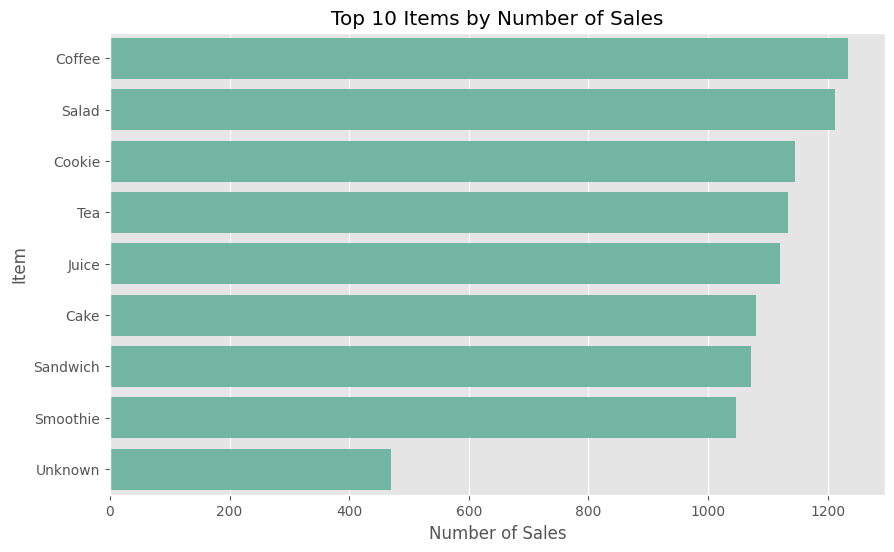

In [32]:
# 11.2 Top items by frequency
top_items = df_clean['Item'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_items.values, y=top_items.index)
plt.title('Top 10 Items by Number of Sales')
plt.xlabel('Number of Sales')
plt.ylabel('Item')
plt.show()

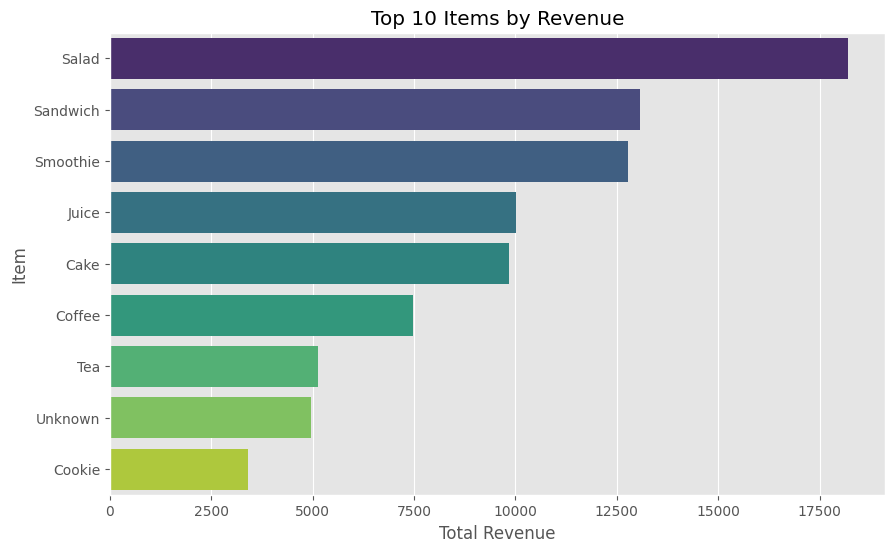

In [33]:
# 11.3 Top items by revenue
revenue_per_item = df_clean.groupby('Item')['Total_Spent'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=revenue_per_item.values, y=revenue_per_item.index, palette='viridis')
plt.title('Top 10 Items by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Item')
plt.show()

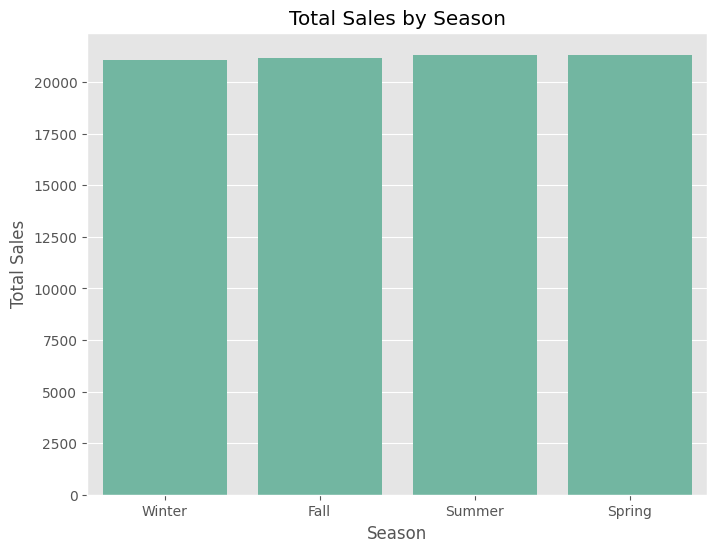

In [34]:
# 11.4 Sales by season
season_sales = df_clean.groupby('Season')['Total_Spent'].sum().sort_values()
plt.figure(figsize=(8,6))
sns.barplot(x=season_sales.index, y=season_sales.values)
plt.title('Total Sales by Season')
plt.xlabel('Season')
plt.ylabel('Total Sales')
plt.show()

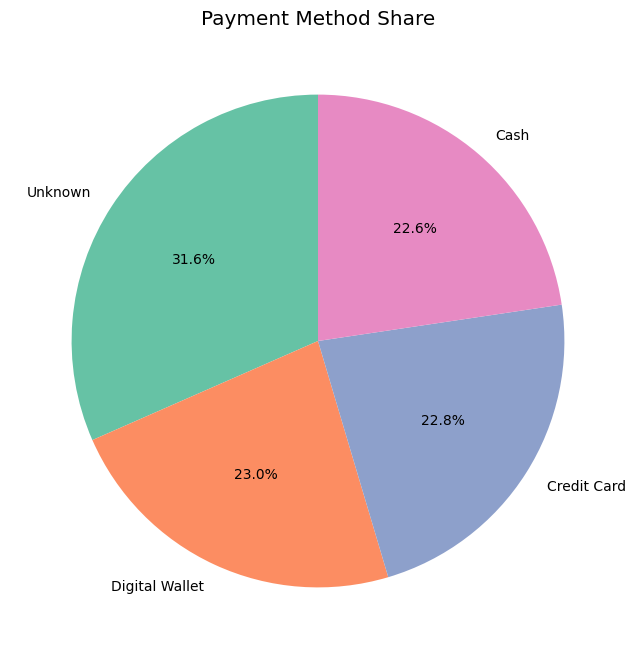

In [35]:
# 11.5 Payment method distribution
payment_counts = df_clean['Payment_Method'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Payment Method Share')
plt.show()

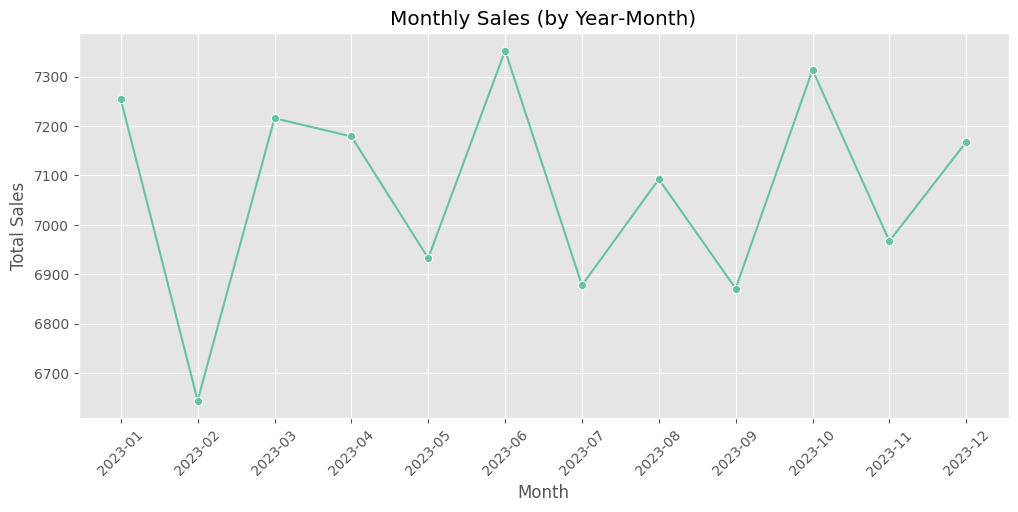

In [36]:
# ---- 11.6 Correct monthly trend (by year‑month) ----
df_clean['YearMonth'] = df_clean['Transaction_Date'].dt.to_period('M')
monthly_sales = df_clean.groupby('YearMonth')['Total_Spent'].sum()

# Convert Period to string for better x‑axis labels
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.title('Monthly Sales (by Year‑Month)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

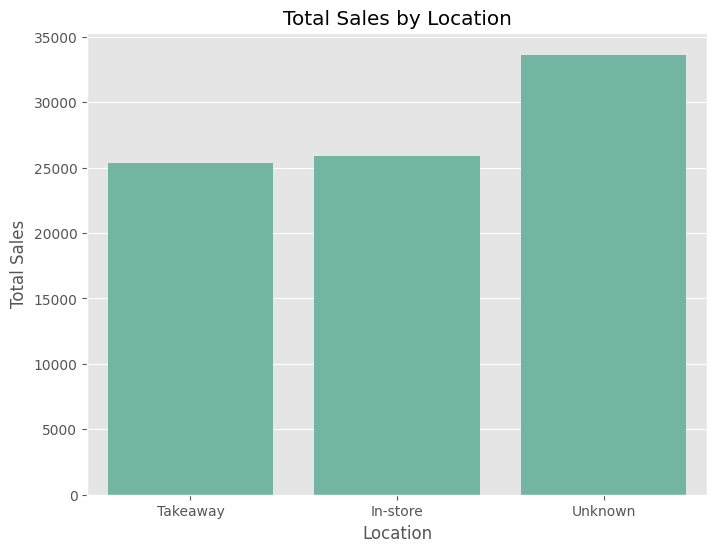

In [37]:
# 11.7 Sales by location
location_sales = df_clean.groupby('Location')['Total_Spent'].sum().sort_values()
plt.figure(figsize=(8,6))
sns.barplot(x=location_sales.index, y=location_sales.values)
plt.title('Total Sales by Location')
plt.xlabel('Location')
plt.ylabel('Total Sales')
plt.show()

## 12. Business KPIs 
Core metrics that any stakeholder reviewing this dataset would expect to see.


In [38]:
# 12.1 Key Performance Indicators
total_transactions = df_clean['Transaction_ID'].nunique()
total_revenue = df_clean['Total_Spent'].sum()
aov = total_revenue / total_transactions  # Average Order Value
avg_qty_per_txn = df_clean['Quantity'].mean()
unique_items = df_clean[df_clean['Item'] != 'Unknown']['Item'].nunique()
avg_price = df_clean['Price_Per_Unit'].mean()

kpi_data = {
    'Metric': [
        'Total Transactions', 'Total Revenue', 'Average Order Value (AOV)',
        'Avg Quantity per Transaction', 'Unique Items Sold', 'Average Unit Price'
    ],
    'Value': [
        f'{total_transactions:,}',
        f'{total_revenue:,.2f}',
        f'{aov:.2f}',
        f'{avg_qty_per_txn:.2f}',
        f'{unique_items}',
        f'{avg_price:.2f}'
    ]
}

kpi_df = pd.DataFrame(kpi_data)
display(kpi_df.style.hide(axis='index').set_properties(**{
    'text-align': 'left', 'font-size': '14px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('font-size', '14px'), ('font-weight', 'bold')]}
]))


Metric,Value
Total Transactions,"9,514"
Total Revenue,"84,868.50"
Average Order Value (AOV),8.92
Avg Quantity per Transaction,3.02
Unique Items Sold,8
Average Unit Price,2.95


### Insight
- The Average Order Value (AOV) tells us how much a typical customer spends per visit — this is the single most important metric for revenue optimization.
- Multiply AOV × daily transaction count to estimate daily revenue capacity.


## 13. Monthly Revenue Trend

The most critical time-series plot for any sales dataset — reveals trends, seasonality, and anomalies.


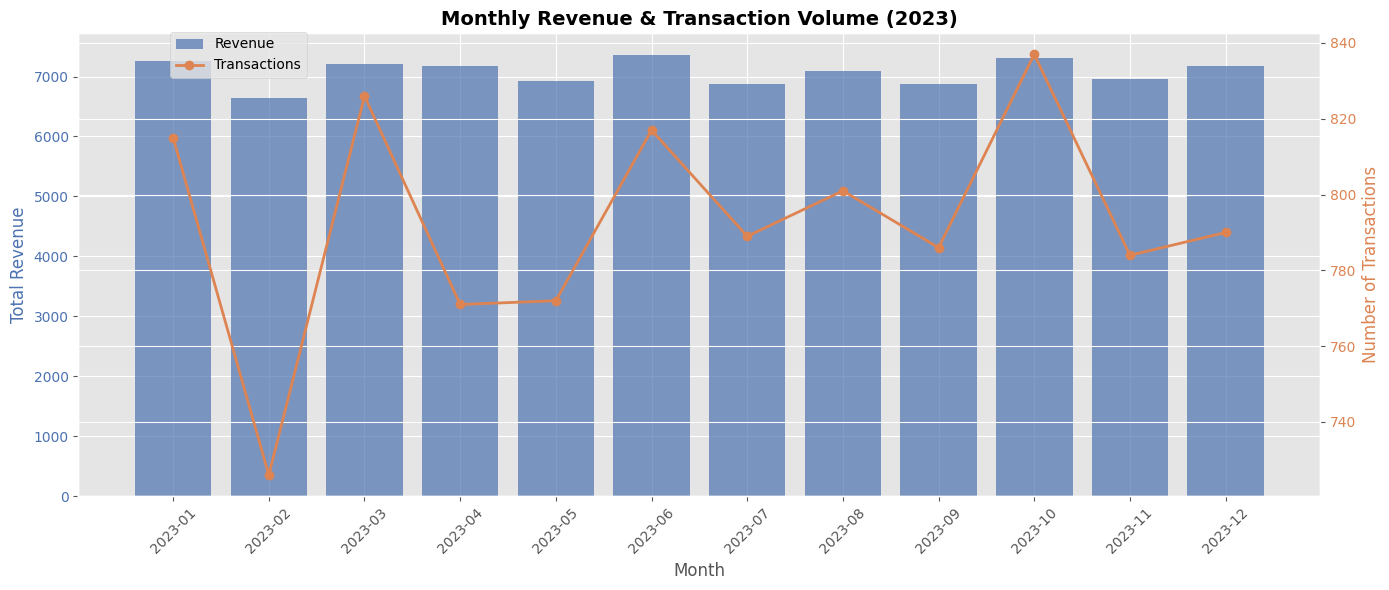

Peak revenue month: 2023-06 (7,353.00)
Lowest revenue month: 2023-02 (6,644.00)


In [39]:
# 13.1 Monthly Revenue Trend
monthly_rev = (
    df_clean.groupby(df_clean['Transaction_Date'].dt.to_period('M'))['Total_Spent']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={'sum': 'Revenue', 'count': 'Transactions', 'mean': 'AOV'})
)
monthly_rev.index = monthly_rev.index.astype(str)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Revenue bars
color_rev = '#4C72B0'
ax1.bar(monthly_rev.index, monthly_rev['Revenue'], color=color_rev, alpha=0.7, label='Revenue')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Total Revenue', fontsize=12, color=color_rev)
ax1.tick_params(axis='y', labelcolor=color_rev)
ax1.tick_params(axis='x', rotation=45)

# Transaction count line on secondary axis
ax2 = ax1.twinx()
color_txn = '#DD8452'
ax2.plot(monthly_rev.index, monthly_rev['Transactions'], color=color_txn,
         marker='o', linewidth=2, label='Transactions')
ax2.set_ylabel('Number of Transactions', fontsize=12, color=color_txn)
ax2.tick_params(axis='y', labelcolor=color_txn)

plt.title('Monthly Revenue & Transaction Volume (2023)', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.show()

# Print summary
print(f"Peak revenue month: {monthly_rev['Revenue'].idxmax()} "
      f"({monthly_rev['Revenue'].max():,.2f})")
print(f"Lowest revenue month: {monthly_rev['Revenue'].idxmin()} "
      f"({monthly_rev['Revenue'].min():,.2f})")


### Insight
- Monthly revenue and transaction volume move together — indicating **no significant change in AOV** across months.
- Identify the peak and trough months above to recommend staffing and inventory adjustments.
- The relatively flat trend suggests this cafe has **stable demand** without strong month-over-month growth or decline.


## 14. Distribution Analysis

Understanding the shape of numerical distributions is essential before drawing conclusions from averages.


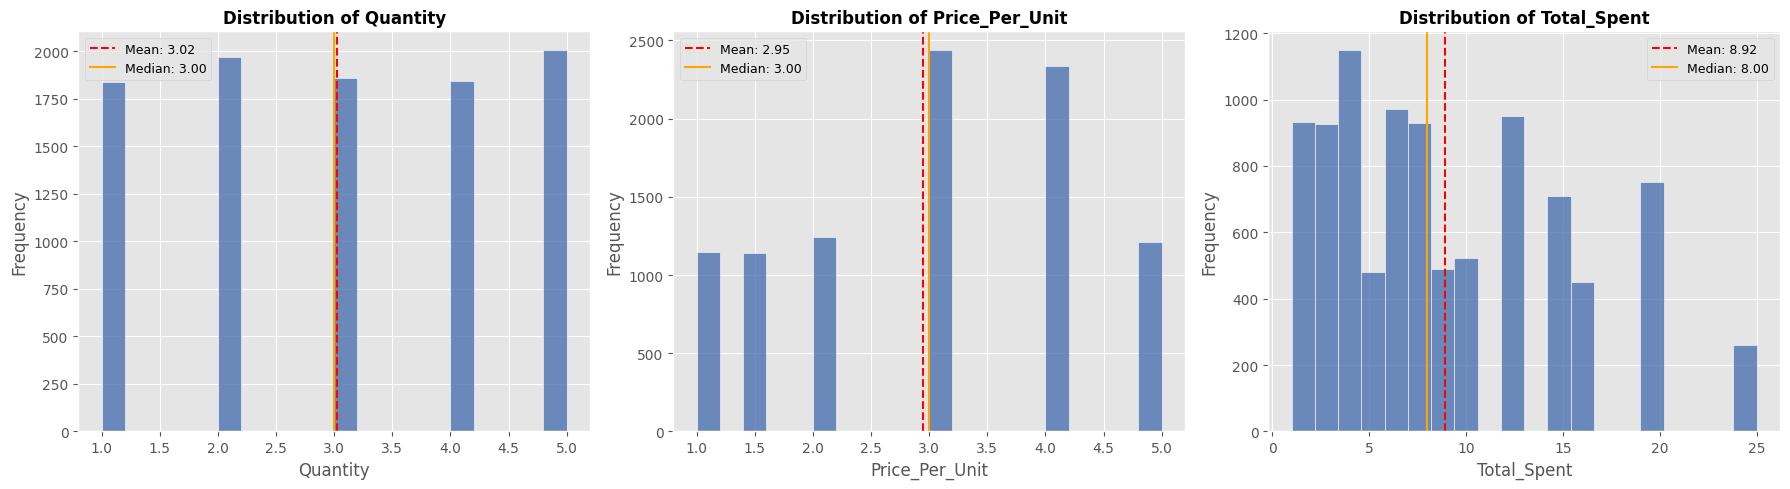

In [40]:
# 14.1 Distribution of Quantity, Price, and Total Spent
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['Quantity', 'Price_Per_Unit', 'Total_Spent']):
    ax = axes[i]
    data = df_clean[col].dropna()

    ax.hist(data, bins=20, color='#4C72B0', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle='-', linewidth=1.5, label=f'Median: {data.median():.2f}')
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### Insight
- **Quantity** is discrete (1–5) and roughly **uniformly distributed** — no single order size dominates.
- **Price_Per_Unit** clusters around a few values (1–5) reflecting the limited menu pricing.
- **Total_Spent** is **right-skewed** — most transactions are small, with a long tail of higher-value orders. This means the **median is a better central tendency measure** than the mean for Total_Spent.


## 15. Item × Location Cross-Analysis 

Which items sell more in-store vs. takeaway? This drives operational decisions like menu placement and packaging.


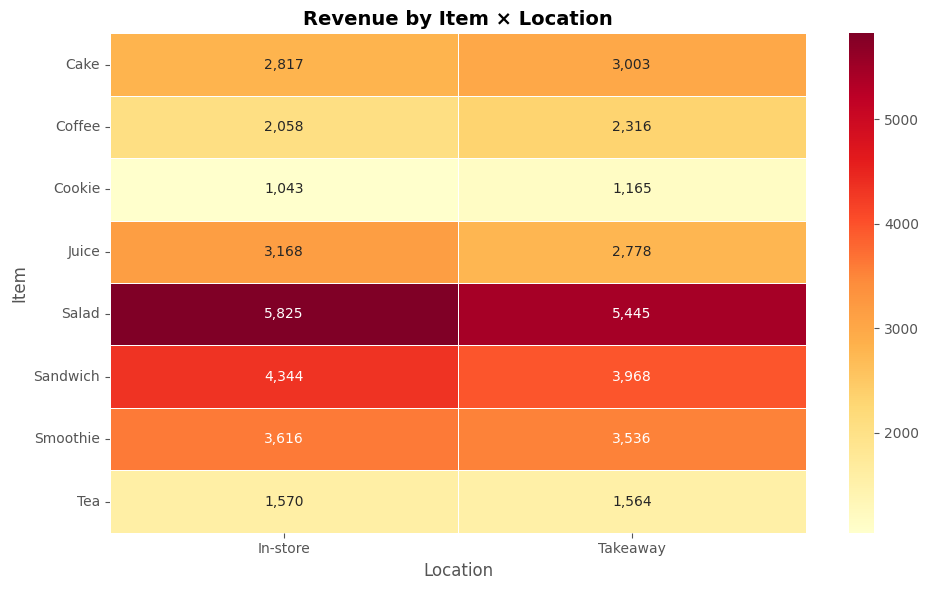

In [41]:
# 15.1 Revenue heatmap: Item × Location
# Exclude 'Unknown' from both dimensions for meaningful analysis
mask = (df_clean['Item'] != 'Unknown') & (df_clean['Location'] != 'Unknown')
cross = df_clean[mask].groupby(['Item', 'Location'])['Total_Spent'].sum().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(cross, annot=True, fmt=',.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Revenue by Item × Location', fontsize=14, fontweight='bold')
plt.ylabel('Item')
plt.xlabel('Location')
plt.tight_layout()
plt.show()


### Insight
- Compare which items generate more revenue **in-store** vs. **takeaway** — items with strong takeaway performance may benefit from delivery partnerships.
- Items that skew heavily toward one location type reveal **customer behavior patterns** (e.g., coffee is a grab-and-go item, while salad may be an in-store item).


## 16. Payment Method × Location Analysis 

Understanding payment preferences by location helps optimize checkout processes.


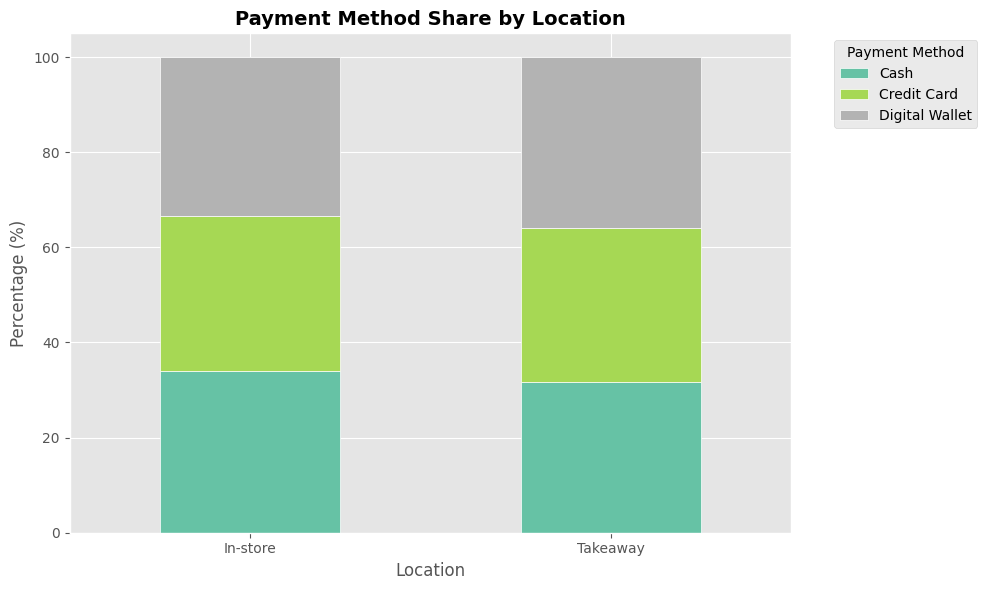

In [42]:
# 16.1 Payment Method distribution by Location
mask = (df_clean['Payment_Method'] != 'Unknown') & (df_clean['Location'] != 'Unknown')
pay_loc = df_clean[mask].groupby(['Location', 'Payment_Method']).size().unstack(fill_value=0)

pay_loc_pct = pay_loc.div(pay_loc.sum(axis=1), axis=0) * 100

pay_loc_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2', edgecolor='white')
plt.title('Payment Method Share by Location', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xlabel('Location')
plt.legend(title='Payment Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Insight
- If **Digital Wallet** dominates takeaway orders, the cafe should ensure its POS system and mobile app are optimized for contactless payments.
- If **Cash** is still significant in-store, removing it entirely would risk losing revenue.


## 17. Correlation Analysis (تحليل الارتباط)

Examining relationships between numerical variables to identify dependencies and potential redundancies.


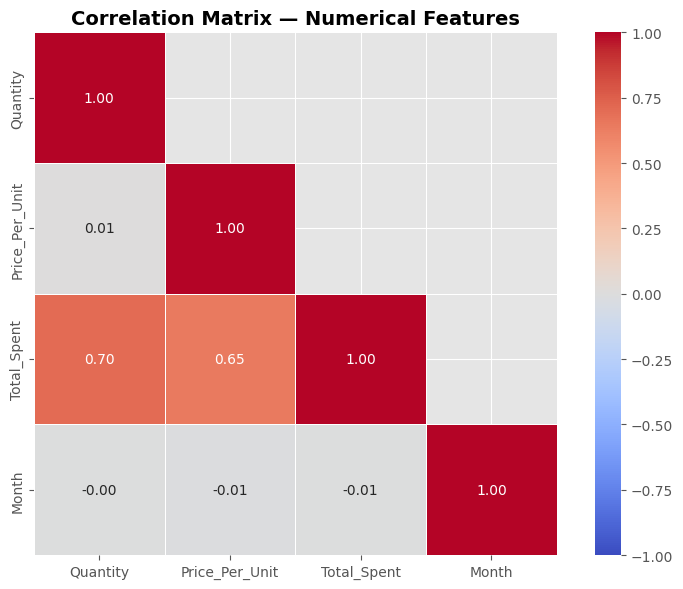

In [43]:
# 17.1 Correlation Matrix
num_cols = ['Quantity', 'Price_Per_Unit', 'Total_Spent', 'Month']
corr_matrix = df_clean[num_cols].corr()

plt.figure(figsize=(8, 6))
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask_upper, square=True, linewidths=0.5,
            vmin=-1, vmax=1)
plt.title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Insight
- **Total_Spent** is mechanically correlated with both **Quantity** and **Price_Per_Unit** (since `Total = Qty × Price`) — this is expected, not a "discovery."
- The interesting finding is whether **Quantity** and **Price_Per_Unit** are correlated: a negative correlation would mean customers buy fewer units of expensive items (rational behavior), while no correlation means price doesn't affect purchase quantity.
- **Month** should show near-zero correlation with all variables — confirming no strong linear seasonality in the data.


## 18. Top Items by Average Order Value

Frequency ≠ Value. An item sold rarely but at high prices may be more profitable than a high-frequency low-price item.


,Transactions,Total_Revenue,Avg_Order_Value,Avg_Quantity,Avg_Price
Item,,,,,
Salad,1212,18200.0,15.02,3.0,5.0
Smoothie,1046,12776.0,12.21,3.05,4.0
Sandwich,1071,13068.0,12.20,3.05,4.0
Cake,1081,9834.0,9.10,3.03,3.0
Juice,1121,10023.0,8.94,2.98,3.0
Coffee,1234,7480.0,6.06,3.03,2.0
Tea,1134,5125.5,4.52,3.01,1.5
Cookie,1145,3414.0,2.98,2.98,1.0


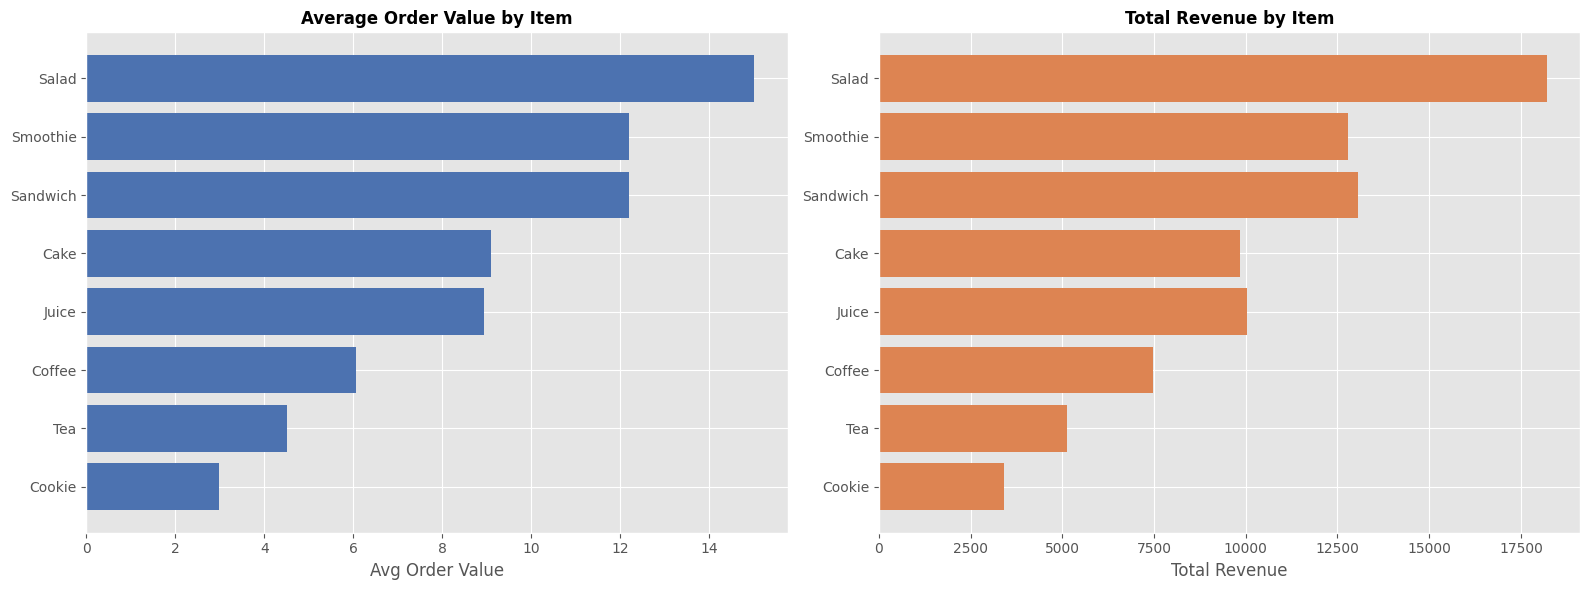

In [44]:
# 18.1 Average Order Value by Item (excluding Unknown)
item_stats = (
    df_clean[df_clean['Item'] != 'Unknown']
    .groupby('Item')
    .agg(
        Transactions=('Transaction_ID', 'count'),
        Total_Revenue=('Total_Spent', 'sum'),
        Avg_Order_Value=('Total_Spent', 'mean'),
        Avg_Quantity=('Quantity', 'mean'),
        Avg_Price=('Price_Per_Unit', 'mean')
    )
    .sort_values('Avg_Order_Value', ascending=False)
)

display(item_stats.round(2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: AOV
axes[0].barh(item_stats.index, item_stats['Avg_Order_Value'], color='#4C72B0')
axes[0].set_title('Average Order Value by Item', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Avg Order Value')
axes[0].invert_yaxis()

# Right: Total Revenue
axes[1].barh(item_stats.index, item_stats['Total_Revenue'], color='#DD8452')
axes[1].set_title('Total Revenue by Item', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Revenue')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


### Insight
- Items with **high AOV but low frequency** are candidates for promotional campaigns to increase volume.
- Items with **high frequency but low AOV** are "traffic drivers" — they bring customers in, who may then purchase higher-value items.
- The **Revenue = Frequency × AOV** framework helps prioritize which items to promote, discount, or bundle.


## 19. Business Insights & Specific Recommendations

In [45]:
# Compute key metrics
total_transactions = len(df_clean)
total_revenue = df_clean['Total_Spent'].sum()
avg_ticket = df_clean['Total_Spent'].mean()

top_item_revenue = df_clean.groupby('Item')['Total_Spent'].sum().idxmax()
top_item_revenue_val = df_clean.groupby('Item')['Total_Spent'].sum().max()

top_item_freq = df_clean['Item'].value_counts().idxmax()
top_item_freq_val = df_clean['Item'].value_counts().max()

best_season = df_clean.groupby('Season')['Total_Spent'].sum().idxmax()
best_season_val = df_clean.groupby('Season')['Total_Spent'].sum().max()
worst_season = df_clean.groupby('Season')['Total_Spent'].sum().idxmin()

top_payment = df_clean['Payment_Method'].value_counts().idxmax()
top_payment_count = df_clean['Payment_Method'].value_counts().max()
top_payment_pct = (top_payment_count / total_transactions) * 100

in_store_sales = df_clean[df_clean['Location'] == 'In-store']['Total_Spent'].sum()
takeaway_sales = df_clean[df_clean['Location'] == 'Takeaway']['Total_Spent'].sum()

print('=== KEY INSIGHTS ===')
print()
print(f'- Total cleaned transactions: {total_transactions:,}')
print(f'- Total revenue: ${total_revenue:,.2f}')
print(f'- Average ticket: ${avg_ticket:.2f}')
print(f'- Highest revenue item: "{top_item_revenue}" (${top_item_revenue_val:,.2f})')
print(f'- Most frequently sold item: "{top_item_freq}" ({top_item_freq_val} times)')
print(f'- Best performing season: {best_season} (${best_season_val:,.2f})')
print(f'- Worst performing season: {worst_season}')
print(f'- Dominant payment method: {top_payment} ({top_payment_count} transactions, {top_payment_pct:.1f}%)')
print(f'- In-store vs Takeaway revenue: ${in_store_sales:,.2f} vs ${takeaway_sales:,.2f}')

print()
print('=== ACTIONABLE RECOMMENDATIONS ===')
print(f'1. Since "{top_item_revenue}" generates the highest revenue (${top_item_revenue_val:,.2f}), consider bundling it with lower-selling items (e.g., "{df_clean.groupby("Item")["Total_Spent"].sum().nsmallest(1).index[0]}") to boost overall sales.')

if top_payment == 'Unknown':
    print('2. Payment method is frequently missing ("Unknown"). Improve data capture at POS/online checkout before drawing conclusions about payment preferences.')
else:
    print(f'2. {top_payment} is used in {top_payment_pct:.1f}% of transactions. Ensure the payment infrastructure for this method is reliable and consider loyalty incentives.')

print(f'3. {best_season} is the peak season; prepare inventory and staffing accordingly. In the weakest season ({worst_season}), launch targeted promotions such as discounts or special menu items.')
print('4. The revenue split between In-store and Takeaway is nearly equal; if Takeaway is slightly lower, consider offering a small discount for takeaway orders to balance load or improve packaging.')


=== KEY INSIGHTS ===

- Total cleaned transactions: 9,514
- Total revenue: $84,868.50
- Average ticket: $8.92
- Highest revenue item: "Salad" ($18,200.00)
- Most frequently sold item: "Coffee" (1234 times)
- Best performing season: Spring ($21,327.50)
- Worst performing season: Winter
- Dominant payment method: Unknown (3005 transactions, 31.6%)
- In-store vs Takeaway revenue: $25,851.50 vs $25,386.50

=== ACTIONABLE RECOMMENDATIONS ===
1. Since "Salad" generates the highest revenue ($18,200.00), consider bundling it with lower-selling items (e.g., "Cookie") to boost overall sales.
2. Payment method is frequently missing ("Unknown"). Improve data capture at POS/online checkout before drawing conclusions about payment preferences.
3. Spring is the peak season; prepare inventory and staffing accordingly. In the weakest season (Winter), launch targeted promotions such as discounts or special menu items.
4. The revenue split between In-store and Takeaway is nearly equal; if Takeaway is sli

## 20. Save Cleaned Data

In [46]:
df_clean.to_csv('output/cleaned_cafe_sales.csv', index=False)
print('Cleaned data saved to output/cleaned_cafe_sales.csv')

Cleaned data saved to output/cleaned_cafe_sales.csv
